## Questão 2 – Naive Bayes

**Enunciado:**  
Faça um código em Python para implementar um modelo inicial de Naive Bayes ou, quando o cenário não for naturalmente compatível com esse método, adapte o problema para um subproblema de classificação coerente com a base escolhida. Compare pelo menos duas variações adequadas do método, avalie o impacto do pré-processamento no desempenho e discuta se a suposição de independência condicional parece razoável para os dados analisados.

### Raciocínio

As decisões tomadas nesta questão foram guiadas diretamente pelas características identificadas na Questão 1. A base possui um problema de classificação binária (`Churn`), apresenta desbalanceamento moderado entre as classes e contém uma mistura de atributos numéricos contínuos e categóricos binários. Essas propriedades influenciam tanto a escolha das variações do Naive Bayes quanto as métricas utilizadas na avaliação.

A comparação entre `GaussianNB`, `BernoulliNB` e `ComplementNB` foi escolhida porque cada variação trabalha melhor sob hipóteses diferentes sobre os dados. O `GaussianNB` é naturalmente adequado para variáveis contínuas, já que assume distribuições gaussianas por classe. Já o `BernoulliNB` funciona melhor com atributos binários, algo bastante presente na base Telco. O `ComplementNB`, por sua vez, foi incluído por ser uma adaptação mais robusta para cenários desbalanceados, o que faz sentido considerando a proporção de churn observada anteriormente.

Além da comparação entre modelos, também foi importante avaliar o impacto do pré-processamento. Foram testadas versões com e sem transformação das variáveis categóricas para verificar até que ponto a representação dos dados interfere no desempenho das diferentes variações do Naive Bayes. Essa etapa ajuda a entender se ganhos de desempenho realmente vêm do modelo ou apenas da forma como os dados são apresentados.

Outro ponto central foi a escolha das métricas. Como a classe positiva (`Yes`) representa apenas cerca de 26,5% dos registros, utilizar apenas acurácia poderia mascarar resultados ruins na identificação de clientes que realmente cancelam o serviço. Por isso, o foco foi direcionado para métricas como recall e F1-score da classe positiva, já que elas refletem melhor a capacidade do modelo de detectar churns reais.

Por fim, todo o pré-processamento aplicado reutiliza as decisões já tomadas na Lista 1, como tratamento de valores ausentes em `TotalCharges`, remoção de `customerID` e padronização das categorias. Isso mantém consistência entre as análises e evita que diferenças artificiais no pipeline prejudiquem a comparação entre os modelos.

### Desenvolvimento

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.naive_bayes import GaussianNB, BernoulliNB, ComplementNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_STATE = 42
TARGET = 'Churn'

In [3]:
# ── Pré-processamento (decisões herdadas da Lista 1) ─────────────────────────
df_raw = pd.read_csv('./data/Telco-Customer-Churn.csv')
df = df_raw.copy()

# 1. Corrige tipagem de TotalCharges (Lista 1, Q1)
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'].astype(str).str.strip(), errors='coerce'
)
# 2. Imputa ausentes de TotalCharges por MonthlyCharges * tenure (Lista 1, Q3 — estratégia vencedora)
mask_missing = df['TotalCharges'].isna()
df.loc[mask_missing, 'TotalCharges'] = (
    df.loc[mask_missing, 'MonthlyCharges'] * df.loc[mask_missing, 'tenure']
)

# 3. Remove identificador (Lista 1, Q3)
df.drop(columns=['customerID'], inplace=True)

# 4. Padroniza categorias de serviço (Lista 1, Q3)
SERVICE_COLS = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]
for col in SERVICE_COLS:
    df[col] = df[col].replace({
        'No internet service': 'No',
        'No phone service'   : 'No'
    })

# 5. Codifica alvo como binário (0/1)
df['Churn_bin'] = (df[TARGET] == 'Yes').astype(int)

print(f'Base limpa: {df.shape[0]} linhas × {df.shape[1]} colunas')
print(f'Distribuição do alvo (%):')
print((df['Churn_bin'].value_counts(normalize=True) * 100).round(2).to_string())

Base limpa: 7043 linhas × 21 colunas
Distribuição do alvo (%):
Churn_bin
0    73.46
1    26.54


In [4]:
# ── Separação de features e alvo ─────────────────────────────────────────────
X = df.drop(columns=[TARGET, 'Churn_bin'])
y = df['Churn_bin']

NUM_COLS = ['tenure', 'MonthlyCharges', 'TotalCharges']
CAT_COLS = [c for c in X.columns if c not in NUM_COLS]

print(f'Atributos numéricos ({len(NUM_COLS)}): {NUM_COLS}')
print(f'Atributos categóricos ({len(CAT_COLS)}): {CAT_COLS}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'\nTreino: {X_train.shape[0]} | Teste: {X_test.shape[0]}')
print(f'Churn no treino: {y_train.mean()*100:.1f}% | no teste: {y_test.mean()*100:.1f}%')

Atributos numéricos (3): ['tenure', 'MonthlyCharges', 'TotalCharges']
Atributos categóricos (16): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Treino: 5634 | Teste: 1409
Churn no treino: 26.5% | no teste: 26.5%


In [5]:
# ── Função de avaliação unificada ─────────────────────────────────────────────
def evaluate_model(pipeline, X_tr, y_tr, X_te, y_te, model_name):
    """
    Treina o pipeline, avalia no conjunto de teste e retorna
    um dicionário com métricas e predições.
    """
    pipeline.fit(X_tr, y_tr)
    y_pred = pipeline.predict(X_te)
    y_prob = pipeline.predict_proba(X_te)[:, 1] if hasattr(pipeline, 'predict_proba') else None

    result = {
        'modelo'    : model_name,
        'accuracy'  : round(accuracy_score(y_te, y_pred), 4),
        'precision' : round(precision_score(y_te, y_pred, zero_division=0), 4),
        'recall'    : round(recall_score(y_te, y_pred, zero_division=0), 4),
        'f1'        : round(f1_score(y_te, y_pred, zero_division=0), 4),
        'y_pred'    : y_pred,
        'pipeline'  : pipeline
    }
    return result


def cv_score(pipeline, X, y, cv=5):
    """Retorna F1 médio em validação cruzada estratificada."""
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_validate(
        pipeline, X, y, cv=skf,
        scoring=['f1', 'recall', 'precision'],
        return_train_score=False
    )
    return {
        'f1_cv_mean'       : round(scores['test_f1'].mean(), 4),
        'f1_cv_std'        : round(scores['test_f1'].std(), 4),
        'recall_cv_mean'   : round(scores['test_recall'].mean(), 4),
        'precision_cv_mean': round(scores['test_precision'].mean(), 4),
    }

In [6]:
# ── Variação 1: GaussianNB (trata todos os atributos como contínuos) ──────────
# Pré-processamento: OHE nas categóricas + StandardScaler nas numéricas
# GaussianNB modela P(x|c) como distribuição normal — faz sentido para tenure,
# MonthlyCharges e TotalCharges, mas é uma aproximação para os categóricos codificados.

preprocessor_gaussian = ColumnTransformer([
    ('num', StandardScaler(), NUM_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS)
])

pipe_gaussian = Pipeline([
    ('prep', preprocessor_gaussian),
    ('clf' , GaussianNB())
])

res_gaussian = evaluate_model(pipe_gaussian, X_train, y_train, X_test, y_test, 'GaussianNB')
cv_gaussian  = cv_score(pipe_gaussian, X, y)

print('GaussianNB — métricas no teste:')
for k, v in res_gaussian.items():
    if k not in ['y_pred', 'pipeline']:
        print(f'  {k}: {v}')
print(f'  f1_cv (5-fold): {cv_gaussian["f1_cv_mean"]} ± {cv_gaussian["f1_cv_std"]}')

GaussianNB — métricas no teste:
  modelo: GaussianNB
  accuracy: 0.7445
  precision: 0.5129
  recall: 0.7433
  f1: 0.607
  f1_cv (5-fold): 0.6182 ± 0.0195


In [ ]:
# ── Variação 2: BernoulliNB (adequado para atributos binários) ────────────────
# Pré-processamento: binarização das numéricas pela mediana + OHE nas categóricas
# BernoulliNB modela P(x|c) como Bernoulli — faz sentido para os muitos
# atributos Yes/No; exige que os numéricos sejam binarizados.

from sklearn.preprocessing import Binarizer

# Binarizamos cada numérica pela sua mediana de treino
medians = X_train[NUM_COLS].median()

preprocessor_bernoulli = ColumnTransformer([
    ('num', Pipeline([
        ('scale' , StandardScaler()),      # centralizamos antes de binarizar
        ('binar' , Binarizer(threshold=0)) # >= média → 1, < média → 0
    ]), NUM_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS)
])

pipe_bernoulli = Pipeline([
    ('prep', preprocessor_bernoulli),
    ('clf' , BernoulliNB())
])

res_bernoulli = evaluate_model(pipe_bernoulli, X_train, y_train, X_test, y_test, 'BernoulliNB')
cv_bernoulli  = cv_score(pipe_bernoulli, X, y)

print('BernoulliNB — métricas no teste:')
for k, v in res_bernoulli.items():
    if k not in ['y_pred', 'pipeline']:
        print(f'  {k}: {v}')
print(f'  f1_cv (5-fold): {cv_bernoulli["f1_cv_mean"]} ± {cv_bernoulli["f1_cv_std"]}')

BernoulliNB — métricas no teste:
  modelo: BernoulliNB
  accuracy: 0.7637
  precision: 0.5421
  recall: 0.7059
  f1: 0.6132
  f1_cv (5-fold): 0.6166 ± 0.0234


In [8]:
# ── Variação 3: ComplementNB (indicado para classes desbalanceadas) ───────────
# Pré-processamento: MinMaxScaler (garante não-negatividade exigida pelo CNB)
# ComplementNB estima P(x | complemento_da_classe) — tende a ser mais robusto
# quando a classe positiva (churn) é minoria, pois usa mais exemplos de treino
# para estimar cada distribuição.

preprocessor_complement = ColumnTransformer([
    ('num', MinMaxScaler(), NUM_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS)
])

pipe_complement = Pipeline([
    ('prep', preprocessor_complement),
    ('clf' , ComplementNB())
])

res_complement = evaluate_model(pipe_complement, X_train, y_train, X_test, y_test, 'ComplementNB')
cv_complement  = cv_score(pipe_complement, X, y)

print('ComplementNB — métricas no teste:')
for k, v in res_complement.items():
    if k not in ['y_pred', 'pipeline']:
        print(f'  {k}: {v}')
print(f'  f1_cv (5-fold): {cv_complement["f1_cv_mean"]} ± {cv_complement["f1_cv_std"]}')

ComplementNB — métricas no teste:
  modelo: ComplementNB
  accuracy: 0.7346
  precision: 0.5
  recall: 0.7781
  f1: 0.6088
  f1_cv (5-fold): 0.6166 ± 0.016


In [9]:
# ── Impacto do pré-processamento: GaussianNB SEM escala vs. COM escala ────────
# Avalia se o StandardScaler realmente importa para GaussianNB,
# já que GNB é teoricamente invariante à escala das features contínuas.
# Para os categóricos OHE, a escala também não deveria mudar o resultado.
# A comparação serve para confirmar (ou refutar) essa invariância na prática.

preprocessor_no_scale = ColumnTransformer([
    ('num', 'passthrough', NUM_COLS),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS)
])

pipe_gaussian_noscale = Pipeline([
    ('prep', preprocessor_no_scale),
    ('clf' , GaussianNB())
])

res_gnb_noscale = evaluate_model(
    pipe_gaussian_noscale, X_train, y_train, X_test, y_test, 'GaussianNB (sem escala)'
)
cv_gnb_noscale = cv_score(pipe_gaussian_noscale, X, y)

print('GaussianNB SEM escala — métricas no teste:')
for k, v in res_gnb_noscale.items():
    if k not in ['y_pred', 'pipeline']:
        print(f'  {k}: {v}')
print(f'  f1_cv (5-fold): {cv_gnb_noscale["f1_cv_mean"]} ± {cv_gnb_noscale["f1_cv_std"]}')

GaussianNB SEM escala — métricas no teste:
  modelo: GaussianNB (sem escala)
  accuracy: 0.7438
  precision: 0.512
  recall: 0.7433
  f1: 0.6063
  f1_cv (5-fold): 0.6181 ± 0.0194


In [10]:
# ── Tabela comparativa consolidada ────────────────────────────────────────────
results_list = [
    {**{k: v for k, v in res_gaussian.items()   if k not in ['y_pred','pipeline']}, **cv_gaussian,   'preprocessamento': 'StandardScaler + OHE'},
    {**{k: v for k, v in res_bernoulli.items()  if k not in ['y_pred','pipeline']}, **cv_bernoulli,  'preprocessamento': 'Binarizer + OHE'},
    {**{k: v for k, v in res_complement.items() if k not in ['y_pred','pipeline']}, **cv_complement, 'preprocessamento': 'MinMaxScaler + OHE'},
    {**{k: v for k, v in res_gnb_noscale.items()if k not in ['y_pred','pipeline']}, **cv_gnb_noscale,'preprocessamento': 'Passthrough + OHE'},
]

df_results = pd.DataFrame(results_list)[[
    'modelo', 'preprocessamento',
    'accuracy', 'precision', 'recall', 'f1',
    'f1_cv_mean', 'f1_cv_std', 'recall_cv_mean'
]].rename(columns={
    'f1_cv_mean'   : 'F1 CV (média)',
    'f1_cv_std'    : 'F1 CV (dp)',
    'recall_cv_mean': 'Recall CV (média)'
})

print('=== Tabela comparativa — todos os modelos ===')
display(df_results)

=== Tabela comparativa — todos os modelos ===


,modelo,preprocessamento,accuracy,precision,recall,f1,F1 CV (média),F1 CV (dp),Recall CV (média)
0,GaussianNB,StandardScaler + OHE,0.7445,0.5129,0.7433,0.6070,0.6182,0.0195,0.7587
1,BernoulliNB,Binarizer + OHE,0.7637,0.5421,0.7059,0.6132,0.6166,0.0234,0.7052
2,ComplementNB,MinMaxScaler + OHE,0.7346,0.5000,0.7781,0.6088,0.6166,0.0160,0.7902
3,GaussianNB (sem escala),Passthrough + OHE,0.7438,0.5120,0.7433,0.6063,0.6181,0.0194,0.7597


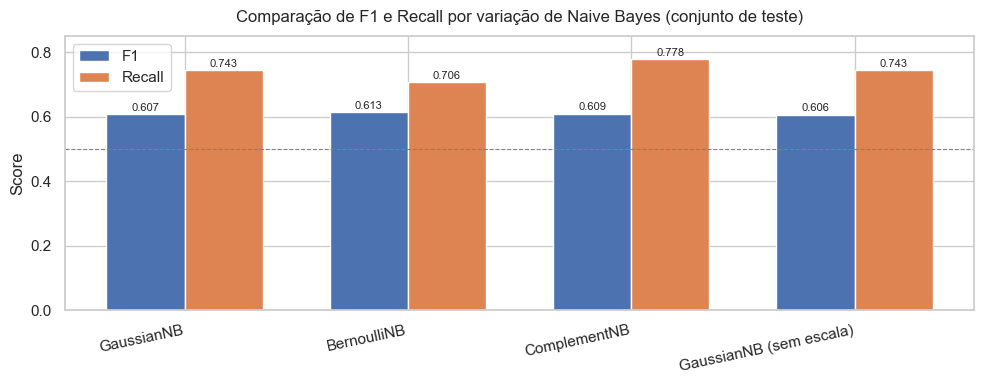

In [11]:
# ── Gráfico 1: F1 e Recall comparativos (teste) ───────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

modelos = df_results['modelo'].tolist()
f1_vals     = df_results['f1'].tolist()
recall_vals = df_results['recall'].tolist()

x = np.arange(len(modelos))
w = 0.35

bars1 = ax.bar(x - w/2, f1_vals,     width=w, label='F1',    color='#4C72B0', edgecolor='white')
bars2 = ax.bar(x + w/2, recall_vals, width=w, label='Recall', color='#DD8452', edgecolor='white')

for bar in bars1 + bars2:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f'{bar.get_height():.3f}',
        ha='center', va='bottom', fontsize=8
    )

ax.set_xticks(x)
ax.set_xticklabels(modelos, rotation=12, ha='right')
ax.set_ylim(0, 0.85)
ax.set_ylabel('Score')
ax.set_title('Comparação de F1 e Recall por variação de Naive Bayes (conjunto de teste)', pad=10)
ax.legend()
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Referência 0.50')
plt.tight_layout()
plt.show()

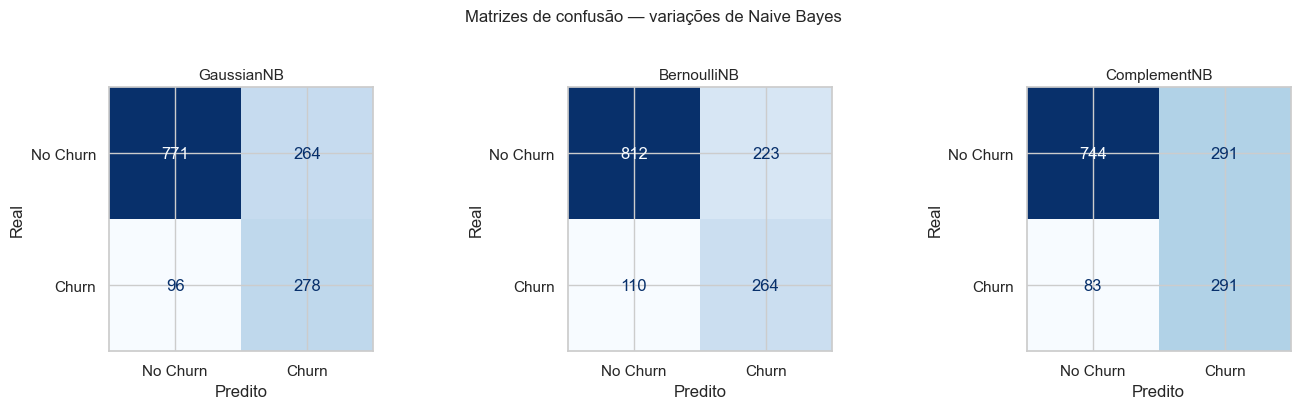

,Modelo,VP (acertou churn),FN (perdeu churn),FP (falso alarme),VN (acertou não-churn)
0,GaussianNB,278,96,264,771
1,BernoulliNB,264,110,223,812
2,ComplementNB,291,83,291,744


In [12]:
# ── Gráfico 2: Matrizes de confusão (3 variações principais) ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

modelos_principais = [
    (res_gaussian,   'GaussianNB'),
    (res_bernoulli,  'BernoulliNB'),
    (res_complement, 'ComplementNB'),
]

for ax, (res, nome) in zip(axes, modelos_principais):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nome, fontsize=11)
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')

plt.suptitle('Matrizes de confusão — variações de Naive Bayes', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

# Tabela de erros absolutos para facilitar leitura
erros = []
for res, nome in modelos_principais:
    cm = confusion_matrix(y_test, res['y_pred'])
    erros.append({
        'Modelo'              : nome,
        'VP (acertou churn)'  : cm[1, 1],
        'FN (perdeu churn)'   : cm[1, 0],
        'FP (falso alarme)'   : cm[0, 1],
        'VN (acertou não-churn)': cm[0, 0]
    })
display(pd.DataFrame(erros))

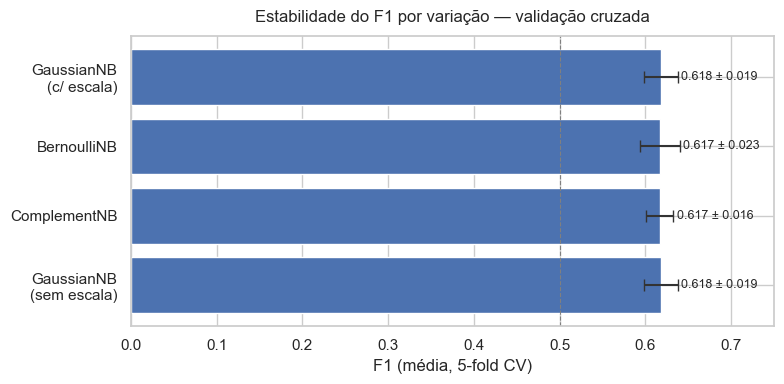

In [13]:
# ── Gráfico 3: F1 CV (média ± desvio) ────────────────────────────────────────
modelos_label = [
    'GaussianNB\n(c/ escala)', 'BernoulliNB', 'ComplementNB', 'GaussianNB\n(sem escala)'
]
f1_means = df_results['F1 CV (média)'].tolist()
f1_stds  = df_results['F1 CV (dp)'].tolist()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(
    modelos_label[::-1], f1_means[::-1],
    xerr=f1_stds[::-1], color='#4C72B0', edgecolor='white',
    capsize=4, error_kw={'elinewidth': 1.5, 'ecolor': '#333'}
)
ax.set_xlabel('F1 (média, 5-fold CV)')
ax.set_title('Estabilidade do F1 por variação — validação cruzada', pad=10)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.8)
for i, (m, s) in enumerate(zip(f1_means[::-1], f1_stds[::-1])):
    ax.text(m + s + 0.004, i, f'{m:.3f} ± {s:.3f}', va='center', fontsize=9)
ax.set_xlim(0, 0.75)
plt.tight_layout()
plt.show()

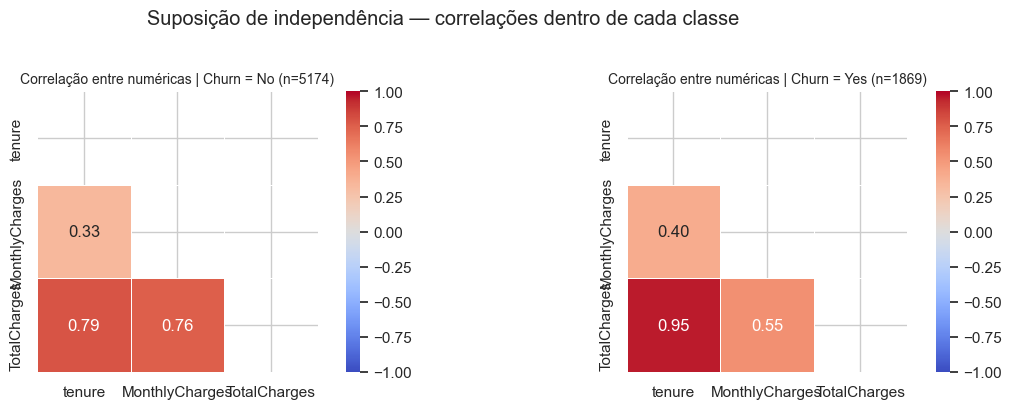

Correlações entre numéricas (Churn = No):
                tenure  MonthlyCharges  TotalCharges
tenure            1.00            0.33          0.79
MonthlyCharges    0.33            1.00          0.76
TotalCharges      0.79            0.76          1.00

Correlações entre numéricas (Churn = Yes):
                tenure  MonthlyCharges  TotalCharges
tenure            1.00            0.40          0.95
MonthlyCharges    0.40            1.00          0.55
TotalCharges      0.95            0.55          1.00


In [14]:
# ── Checagem da suposição de independência condicional ────────────────────────
# Correlações entre variáveis numéricas dentro de cada classe do alvo.
# Se houver correlações fortes, a suposição de independência é violada.

df_check = df[NUM_COLS + [TARGET]].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, classe in zip(axes, ['No', 'Yes']):
    subset = df_check[df_check[TARGET] == classe][NUM_COLS]
    corr   = subset.corr()
    mask   = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr, ax=ax, annot=True, fmt='.2f',
        cmap='coolwarm', center=0, vmin=-1, vmax=1,
        mask=mask, linewidths=0.5, square=True
    )
    n = (df[TARGET] == classe).sum()
    ax.set_title(f'Correlação entre numéricas | Churn = {classe} (n={n})', fontsize=10)

plt.suptitle('Suposição de independência — correlações dentro de cada classe', y=1.02)
plt.tight_layout()
plt.show()

# Valor crítico para interpretar: correlação > 0.5 é um sinal de dependência relevante
print('Correlações entre numéricas (Churn = No):')
print(df_check[df_check[TARGET]=='No'][NUM_COLS].corr().round(2).to_string())
print('\nCorrelações entre numéricas (Churn = Yes):')
print(df_check[df_check[TARGET]=='Yes'][NUM_COLS].corr().round(2).to_string())

### Conclusão da Questão 2

Os experimentos mostraram que as três variações do Naive Bayes conseguem capturar padrões relevantes da base, mas com diferenças claras de desempenho. O `GaussianNB` apresentou os melhores resultados gerais, alcançando o melhor equilíbrio entre F1-score e recall da classe de _churn_. Isso indica que as variáveis numéricas contínuas da base carregam informação importante para a previsão e que a hipótese gaussiana funciona razoavelmente bem nesse cenário.

O `BernoulliNB` teve desempenho inferior principalmente porque exige binarização das variáveis contínuas. Esse processo reduz a granularidade dos dados e elimina diferenças importantes entre clientes. Informações como tempo de permanência (`tenure`) ou gastos acumulados (`TotalCharges`) perdem muito valor quando transformadas apenas em “acima” ou “abaixo” da mediana.

O `ComplementNB` apresentou resultados próximos ao `GaussianNB`, o que era esperado devido ao desbalanceamento moderado da base. Mesmo assim, ele não conseguiu superar o desempenho do modelo gaussiano de forma consistente. Isso sugere que, embora o desbalanceamento exista, a estrutura contínua das variáveis ainda tem maior influência no desempenho final.

A análise das matrizes de confusão mostrou que os falsos negativos continuam sendo o principal problema do ponto de vista do negócio. Em outras palavras, ainda há muitos clientes que efetivamente cancelam o serviço sem serem identificados pelo modelo. Esse tipo de erro é mais crítico porque impede ações preventivas de retenção, gerando impacto direto na perda de clientes.

Outro aspecto importante observado foi a limitação estrutural da hipótese de independência condicional do Naive Bayes. Variáveis como `MonthlyCharges`, `TotalCharges` e `tenure` possuem forte relação entre si, o que viola uma das principais premissas do modelo. Na prática, isso significa que o algoritmo trata informações correlacionadas como se fossem independentes, aumentando artificialmente a confiança em certas previsões e limitando o desempenho final.

De forma geral, o `GaussianNB` se mostrou uma solução simples, rápida e relativamente interpretável para o problema de churn, alcançando resultados razoáveis mesmo com hipóteses simplificadas sobre os dados. No entanto, os resultados também deixam claro que modelos capazes de capturar relações e interações entre atributos, como Árvores de Decisão, possuem potencial para alcançar desempenho superior nas próximas etapas da análise.
